In [1]:
import pandas as pd
import numpy as np

#steps we do

#### 0.Preprocess +EDA +feature selection
#### 1.extract input and output cols
#### 2. scale the values
#### 3. Train test split
#### 4.train the model
#### 5. evaluate the model/model selection
#### 6.deploy the model

In [3]:
df = pd.read_csv("placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
import matplotlib.pyplot as plt


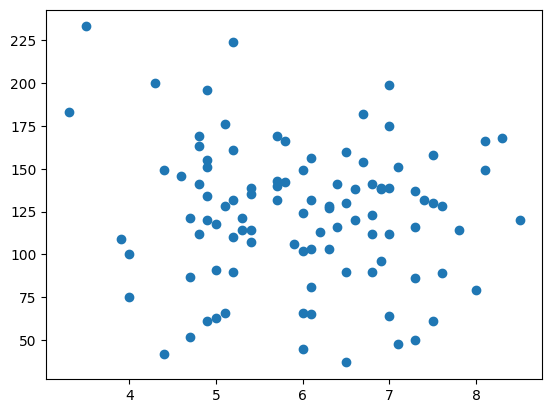

In [9]:
plt.scatter(df['cgpa'],df['iq'])

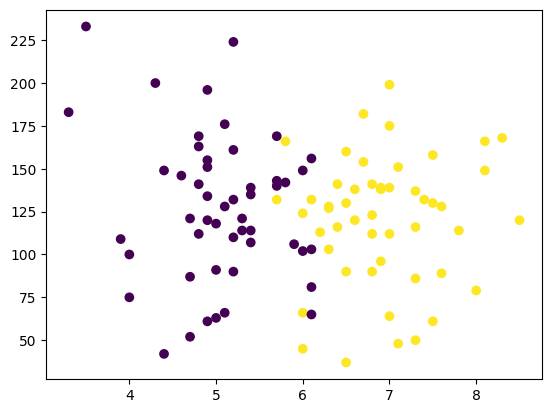

In [10]:
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])

yellow - placement , black - no placement

In [12]:
X = df.iloc[:,0:2] #independent ->CGPA, IQ
Y = df.iloc[:,-1] #dependent ->placement

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [15]:
Y.shape

(100,)

test split

In [22]:
from sklearn.model_selection import train_test_split
train_test_split(X,Y,test_size=0.1)  #10% test

[    cgpa     iq
 36   5.7  140.0
 31   3.9  109.0
 57   6.5  130.0
 6    5.7  143.0
 75   4.8  169.0
 ..   ...    ...
 33   6.0  149.0
 49   5.4  135.0
 91   7.5  158.0
 88   4.4  149.0
 93   6.8  112.0
 
 [90 rows x 2 columns],
     cgpa     iq
 96   4.4   42.0
 55   7.8  114.0
 60   6.9  139.0
 2    5.3  121.0
 80   4.9  196.0
 30   7.6  128.0
 48   6.6  138.0
 84   5.7  169.0
 52   7.0  175.0
 82   6.5   37.0,
 36    0
 31    0
 57    1
 6     0
 75    0
      ..
 33    0
 49    0
 91    1
 88    0
 93    1
 Name: placement, Length: 90, dtype: int64,
 96    0
 55    1
 60    1
 2     0
 80    0
 30    1
 48    1
 84    0
 52    1
 82    1
 Name: placement, dtype: int64]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)  #10% test

In [24]:
X_train

,cgpa,iq
7,5.0,63.0
14,6.1,103.0
96,4.4,42.0
76,4.9,155.0
87,5.7,132.0
...,...,...
15,5.1,176.0
26,7.0,199.0
23,4.7,87.0
30,7.6,128.0


## scaling

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [31]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
X_train

array([[-0.88826784, -1.55728542],
       [ 0.14508723, -0.54129638],
       [-1.45191606, -2.09067967],
       [-0.98220921,  0.77948937],
       [-0.23067825,  0.19529567],
       [-1.82768154, -0.61749556],
       [ 0.05114586, -2.01448049],
       [-1.17009195, -0.08410131],
       [-1.07615058,  0.4238932 ],
       [ 0.52085271,  0.906488  ],
       [-0.13673688,  0.44929293],
       [ 1.46026641,  0.14449622],
       [-1.26403332,  0.55089183],
       [ 0.89661819, -0.71909446],
       [-1.92162291, -0.38889803],
       [ 1.36632504,  0.19529567],
       [ 0.14508723, -1.50648597],
       [-0.51250236,  0.27149485],
       [ 2.02391463,  1.05888635],
       [-0.98220921,  1.82087813],
       [ 2.02391463,  0.62709101],
       [ 0.42691134,  0.4238932 ],
       [-0.98220921,  0.24609512],
       [ 0.99055956, -0.31269885],
       [ 0.89661819,  0.37309375],
       [-0.60644373, -0.08410131],
       [ 0.52085271, -2.2176783 ],
       [ 0.05114586, -0.56669611],
       [ 0.70873545,

In [32]:
X_test

array([[ 1.27238367, -1.88748186],
       [-0.88826784, -0.84609309],
       [ 1.55420778, -0.89689255],
       [-0.7003851 , -0.3634983 ],
       [ 2.39968011, -0.10950104],
       [-1.54585743,  1.92247704],
       [ 1.92997326, -1.15088981],
       [ 2.21179737,  1.10968581],
       [-0.51250236, -0.2618994 ],
       [-1.45191606,  0.62709101]])

## model training

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
clf = LogisticRegression()

In [35]:
#model train
clf.fit(X_train,Y_train)

LogisticRegression()

In [37]:
y_pred = clf.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

1.0

## which pattern ml use for that we use this code ->mlxtred

<Axes: >

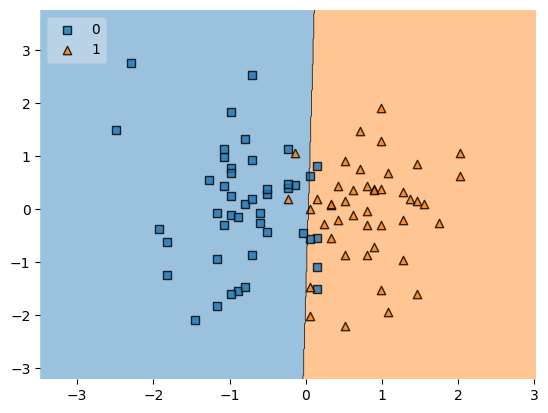

In [41]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train ,Y_train.values,clf=clf,legend=2)

## pickle -> any object convert into file

In [42]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))